In [1]:
# Cell 1: Setup and Imports
import sys
import os
import logging

# Configure notebook logging to show INFO messages
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S"
)

# Add Scripts directory to path
current_dir = os.getcwd()
scripts_path = os.path.join(current_dir, "Scripts")
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from dynawo_notebooks.Scripts.core.mo_topology import MoTopologyToolkit
from IPython.display import SVG, display

# Configurations
SOURCE_DIR = "Models"
MODEL_NAME = "Dynawo.Examples.BESS.WECC.MyBESS_static"
DYNAWO_PKG = "/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"
LOCAL_FILES = ["MyBESS_static.mo", "BESS_init.mo"]

print("Toolkit loaded.")

Toolkit loaded.


In [2]:
# Cell 2: Extraction and Parsing
try:
    # Instantiate the Toolkit (Facade)
    toolkit = MoTopologyToolkit(SOURCE_DIR, MODEL_NAME, DYNAWO_PKG, LOCAL_FILES)

    # Execute Parsing Pipeline
    parsed_data = toolkit.parse_electrical_data()

    # Export for verification
    toolkit.export_to_standard_json(parsed_data, "grid_export.json")

    print(f"Parsing successful. Found {len(parsed_data['generators'])} generators.")

except Exception as e:
    print(f"An error occurred: {e}")

11:21:06 [INFO] ============================================================
11:21:06 [INFO] Initializing MoTopologyToolkit for model: Dynawo.Examples.BESS.WECC.MyBESS_static
11:21:06 [INFO] ============================================================
11:21:06 [INFO] Connecting to OpenModelica Compiler (OMC)...
11:21:07 [INFO] Local OMC Server is up and running at ZMQ port tcp://127.0.0.1:44323 pid=13865
11:21:07 [INFO] OMC Session established successfully.
11:21:07 [INFO] Loading Standard Modelica Libraries...
11:21:08 [INFO] Loading Dynawo Package from: /home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo
11:21:08 [INFO] Loading local models from: /home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Models
11:21:08 [INFO] Verifying integrity of model 'Dynawo.Examples.BESS.WECC.MyBESS_static'...
11:21:09 [WARNING] [OMC log for 'sendExpression(checkModel(Dynawo.Examples.BESS.WECC.MyBESS_static), True)']: [translation:warning:150] Connector switchOffSignal3 is not balanc

Parsing successful. Found 1 generators.


In [3]:
# Cell 3: Build PowSybl Network
try:
    network = toolkit.build_powsybl_network(parsed_data)

    print("Network constructed successfully.")
    print(f"- Buses: {len(network.get_buses())}")
    print(f"- Lines: {len(network.get_lines())}")
    print(f"- Generators: {len(network.get_generators())}")
    print(f"- Loads: {len(network.get_loads())}")
    print(f"- Shunts: {len(network.get_shunt_compensators())}")

except Exception as e:
    print(f"Network build failed: {e}")

11:21:09 [INFO] >>> STEP 2: CONVERTING TO POWSYBL
11:21:09 [INFO] Initializing PyPowSybl Network construction...
11:21:09 [INFO] PyPowSybl Network object created successfully.


Network constructed successfully.
- Buses: 2
- Lines: 1
- Generators: 1
- Loads: 0
- Shunts: 0


Displaying Network Diagram:


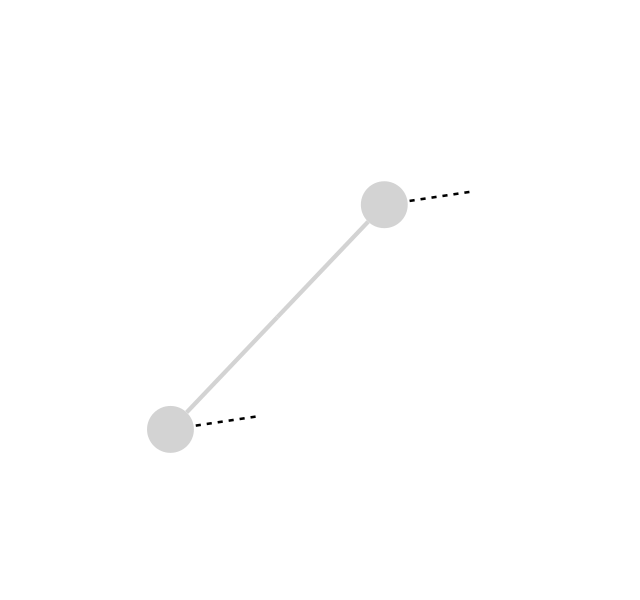

In [4]:
# Cell 4: Visualization
try:
    nad_svg = network.get_network_area_diagram()
    print("Displaying Network Diagram:")
    display(SVG(str(nad_svg)))
except Exception as e:
    print(f"Visualization failed: {e}")